In [41]:
!pip install mlflow dagshub

In [42]:
import mlflow
import dagshub

dagshub.init(
    repo_owner="abdoslamalsalm-hash",
    repo_name="my-first-repo",
    mlflow=True
)

Initialized MLflow to track repo "abdoslamalsalm-hash/my-first-repo"

Repository abdoslamalsalm-hash/my-first-repo initialized!

In [43]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

Check current runtime

In [44]:
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Download & un the data

In [45]:
def get_data_extract():
  if "dataset" in os.listdir():
    print("Dataset already exists")
  else:
    print("Downloading the data...")
    !wget -O food-data.zip https://www.kaggle.com/api/v1/datasets/download/trolukovich/food11-image-dataset
    print("Dataset downloaded!")
    print("Extracting data..")
    !mkdir dataset
    !unzip -q food-data.zip -d dataset
    print("Extraction done!")

get_data_extract()


Dataset already exists


# Dataset

In [46]:
data_dir = "dataset/Food11"

train_dir = os.path.join(data_dir, "training")
val_dir = os.path.join(data_dir, "validation")
test_dir = os.path.join(data_dir, "evaluation")

print("Train:", train_dir)
print("Validation:", val_dir)
print("Test:", test_dir)

Train: dataset/Food11/training
Validation: dataset/Food11/validation
Test: dataset/Food11/evaluation


Create Dataset from list of path

In [47]:
path = glob.glob("dataset/*/*/*.jpg")
class_names = sorted(list(set([i.split(".")[0].split("/")[-2] for i in path])))
class_to_index = {name: idx for idx, name in enumerate(class_names)}

label = [class_to_index[i.split(".")[0].split("/")[-2]] for i in path]

Image augmentation

In [48]:
image_width, image_height = 224,224

aug = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
])

Dataloader

In [49]:
def load_image(path, label, aug):
  image = tf.io.read_file(path)
  image = tf.image.decode_jpeg(image, channels=3)
  image = tf.cast(image, tf.float32)
  image = tf.image.resize(image, (image_width, image_height))
  return image, label

In [50]:
ds = tf.data.Dataset.from_tensor_slices((path, label))
ds=ds.shuffle(buffer_size=len(path), reshuffle_each_iteration=False) # disable reshuffle_each_iteration to prevent data leak
ds = ds.map(lambda x, y: load_image(x, y, aug), num_parallel_calls=tf.data.AUTOTUNE).batch(16).prefetch(tf.data.AUTOTUNE)

In [51]:
class_names

['Bread',
 'Dairy product',
 'Dessert',
 'Egg',
 'Fried food',
 'Meat',
 'Noodles-Pasta',
 'Rice',
 'Seafood',
 'Soup',
 'Vegetable-Fruit']

In [52]:
num_classes = len(class_names)
num_classes

11

In [53]:
dataset_size = len(path)
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_ds = ds.take(train_size // 16)
remaining_ds = ds.skip(train_size // 16)

val_ds = remaining_ds.take(val_size // 16)
test_ds = remaining_ds.skip(val_size // 16)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Train batches: 728
Validation batches: 156
Test batches: 157


In [54]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)


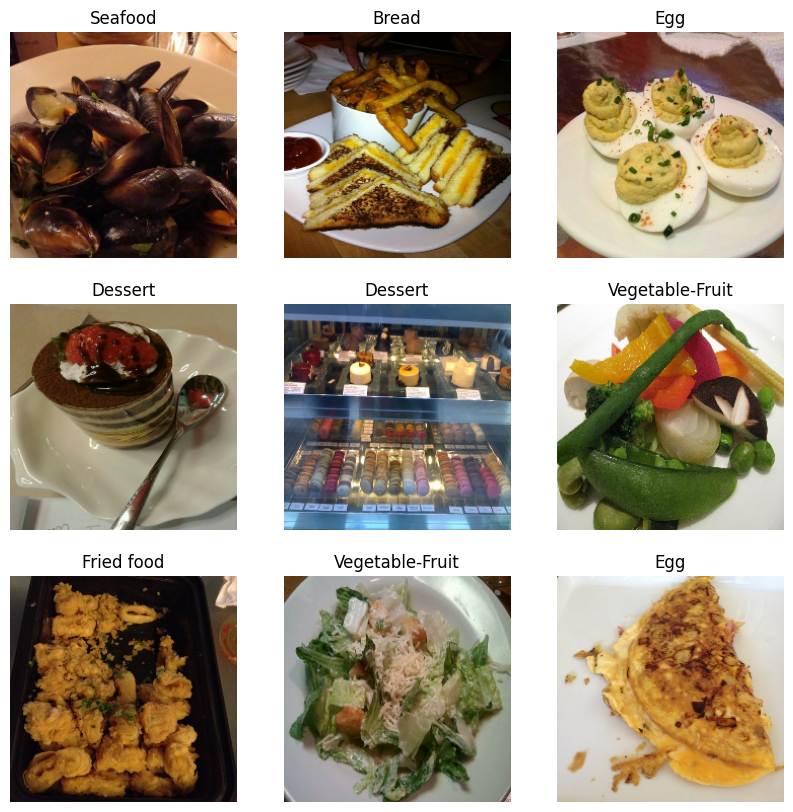

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(tf.cast(images[i] / 255.0, tf.float32).numpy())
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
plt.show()

Display Sample from our custom dataset

In [56]:
print("Sample from the dataset:",next(iter(ds))[1])

Sample from the dataset: tf.Tensor([ 8  0  3  2  2 10  4 10  3  3  5  6  9  0  5  5], shape=(16,), dtype=int32)


# Model

In [57]:
base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = keras.Input(shape=(224,224,3))
x = aug(inputs)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

In [58]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │        14,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,068,782 (15.52 MB)

 Trainable params: 16,651 (65.04 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [59]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2
    )
]

In [60]:
history_feature_extraction = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 94s 103ms/step - accuracy: 0.7165 - loss: 0.9226 - val_accuracy: 0.8674 - val_loss: 0.4330 - learning_rate: 0.0010
Epoch 2/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 73s 100ms/step - accuracy: 0.8096 - loss: 0.5981 - val_accuracy: 0.8770 - val_loss: 0.4046 - learning_rate: 0.0010
Epoch 3/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 80s 98ms/step - accuracy: 0.8288 - loss: 0.5386 - val_accuracy: 0.8778 - val_loss: 0.3990 - learning_rate: 0.0010
Epoch 4/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 71s 97ms/step - accuracy: 0.8376 - loss: 0.5116 - val_accuracy: 0.8746 - val_loss: 0.3945 - learning_rate: 0.0010
Epoch 5/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 72s 98ms/step - accuracy: 0.8407 - loss: 0.4969 - val_accuracy: 0.8770 - val_loss: 0.4043 - learning_rate: 0.0010
Epoch 6/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 71s 97ms/step - accuracy: 0.8381 - loss: 0.4951 - val_accuracy: 0.8838 - val_loss: 0.3915 - learning_rate: 0.0010
Epoch 7/10
728/728 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.8470 -

In [61]:
feature_extraction_results = model.evaluate(test_ds)

print("Feature Extraction Test Loss:", feature_extraction_results[0])
print("Feature Extraction Test Accuracy:", feature_extraction_results[1])

157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - accuracy: 0.8896 - loss: 0.3370
Feature Extraction Test Loss: 0.3370025157928467
Feature Extraction Test Accuracy: 0.889555811882019


In [62]:
with mlflow.start_run(run_name="Feature_Extraction"):

    mlflow.log_param("model", "EfficientNetB0")
    mlflow.log_param("approach", "Feature Extraction")

    mlflow.log_metric("test_accuracy", feature_extraction_results[1])
    mlflow.log_metric("test_loss", feature_extraction_results[0])

🏃 View run Feature_Extraction at: https://dagshub.com/abdoslamalsalm-hash/my-first-repo.mlflow/#/experiments/0/runs/69a07789588a4668a2f06993f7748dbd
🧪 View experiment at: https://dagshub.com/abdoslamalsalm-hash/my-first-repo.mlflow/#/experiments/0


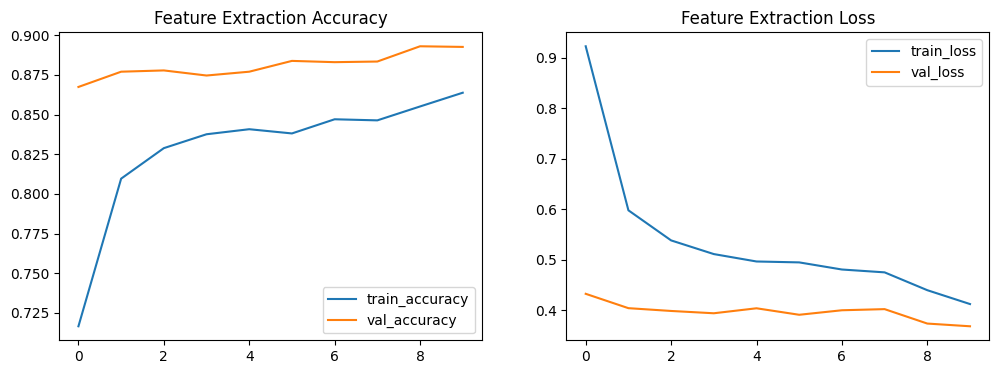

<Figure size 640x480 with 0 Axes>

In [75]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_feature_extraction.history["accuracy"], label="train_accuracy")
plt.plot(history_feature_extraction.history["val_accuracy"], label="val_accuracy")
plt.title("Feature Extraction Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_feature_extraction.history["loss"], label="train_loss")
plt.plot(history_feature_extraction.history["val_loss"], label="val_loss")
plt.title("Feature Extraction Loss")
plt.legend()

plt.show()
plt.savefig("training_plots.png")

In [76]:
import mlflow

with mlflow.start_run(run_name="Artifacts"):
    mlflow.log_artifact("training_plots.png")

🏃 View run Artifacts at: https://dagshub.com/abdoslamalsalm-hash/my-first-repo.mlflow/#/experiments/0/runs/d293f61b096345278a39c3d4cbf43a1a
🧪 View experiment at: https://dagshub.com/abdoslamalsalm-hash/my-first-repo.mlflow/#/experiments/0


## Fine-tuning


In [64]:
base_model.trainable = True

In [65]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [66]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [67]:
history_fine_tuning = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
728/728 ━━━━━━━━━━━━━━━━━━━━ 96s 114ms/step - accuracy: 0.7297 - loss: 0.8527 - val_accuracy: 0.8526 - val_loss: 0.5064 - learning_rate: 1.0000e-05
Epoch 2/5
728/728 ━━━━━━━━━━━━━━━━━━━━ 78s 107ms/step - accuracy: 0.7847 - loss: 0.6668 - val_accuracy: 0.8714 - val_loss: 0.4584 - learning_rate: 1.0000e-05
Epoch 3/5
728/728 ━━━━━━━━━━━━━━━━━━━━ 81s 111ms/step - accuracy: 0.7986 - loss: 0.6201 - val_accuracy: 0.8730 - val_loss: 0.4522 - learning_rate: 2.0000e-06


In [68]:
fine_tuning_results = model.evaluate(test_ds)
print("Fine-tuning Test Loss:", fine_tuning_results[0])
print("Fine-tuning Test Accuracy:", fine_tuning_results[1])

157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.8495 - loss: 0.4849
Fine-tuning Test Loss: 0.48491212725639343
Fine-tuning Test Accuracy: 0.8495398163795471


In [69]:
with mlflow.start_run(run_name="Fine_Tuning"):

    mlflow.log_param("model", "EfficientNetB0")
    mlflow.log_param("approach", "Fine Tuning")

    mlflow.log_metric("test_accuracy", fine_tuning_results[1])
    mlflow.log_metric("test_loss", fine_tuning_results[0])

🏃 View run Fine_Tuning at: https://dagshub.com/abdoslamalsalm-hash/my-first-repo.mlflow/#/experiments/0/runs/1372975fbd154b3ba02714900fc15f99
🧪 View experiment at: https://dagshub.com/abdoslamalsalm-hash/my-first-repo.mlflow/#/experiments/0


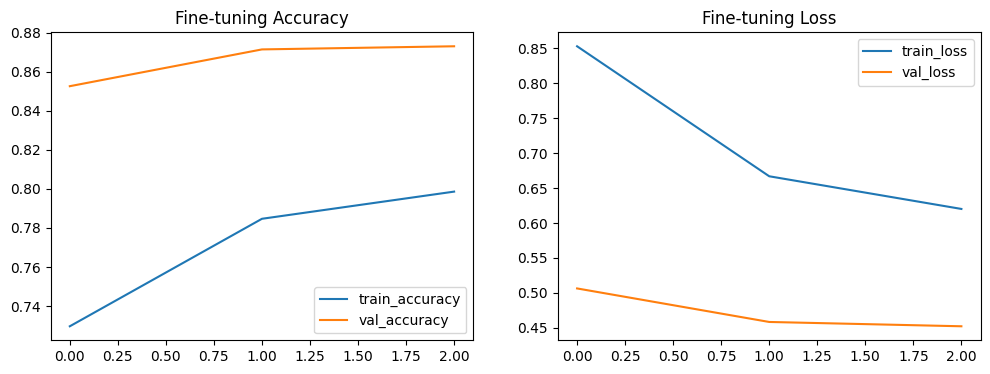

In [70]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_fine_tuning.history["accuracy"], label="train_accuracy")
plt.plot(history_fine_tuning.history["val_accuracy"], label="val_accuracy")
plt.title("Fine-tuning Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_fine_tuning.history["loss"], label="train_loss")
plt.plot(history_fine_tuning.history["val_loss"], label="val_loss")
plt.title("Fine-tuning Loss")
plt.legend()

plt.show()

مقارنه النهائيه


In [71]:
print("Feature Extraction Accuracy:", feature_extraction_results[1])
print("Fine-tuning Accuracy:", fine_tuning_results[1])

Feature Extraction Accuracy: 0.889555811882019
Fine-tuning Accuracy: 0.8495398163795471


In [72]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_classes = tf.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes.numpy())

In [73]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

                 precision    recall  f1-score   support

          Bread       0.85      0.78      0.81       258
  Dairy product       0.80      0.85      0.82       116
        Dessert       0.84      0.77      0.80       384
            Egg       0.78      0.79      0.78       252
     Fried food       0.77      0.84      0.80       226
           Meat       0.84      0.89      0.86       324
  Noodles-Pasta       0.93      0.96      0.94       113
           Rice       0.89      0.87      0.88        78
        Seafood       0.83      0.84      0.83       215
           Soup       0.93      0.95      0.94       373
Vegetable-Fruit       0.93      0.87      0.90       160

       accuracy                           0.85      2499
      macro avg       0.85      0.86      0.85      2499
   weighted avg       0.85      0.85      0.85      2499



In [74]:
model.save("efficientnet_food11_transfer_learning.keras")

In [77]:
import mlflow

with mlflow.start_run(run_name="Model_Artifact"):

    mlflow.keras.log_model(model, "trained_model")

2026/03/13 03:12:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 03:12:55 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run Model_Artifact at: https://dagshub.com/abdoslamalsalm-hash/my-first-repo.mlflow/#/experiments/0/runs/391b360576d24116ab722510df59e3c6
🧪 View experiment at: https://dagshub.com/abdoslamalsalm-hash/my-first-repo.mlflow/#/experiments/0
